# Hits, effects and cell loss

This page asks which treatments moved away from the controls, which measurements changed, and whether a hit is
a phenotype or cells that died. Hit calls come with a permutation p-value and feature effects with
Mann-Whitney q-values.

Potency has its own page, [Concentration response](dose_response.ipynb). The same questions asked of single
cells are on [What the well median hides](../single_cells/heterogeneity.ipynb).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc

import mantispy as mt

## A screen with replicates

`pki` is the JUMP pilot's kinase inhibitor set: fifteen compounds in U2OS, eleven of them at three doses, with 32 to 64
replicate wells per treatment {cite:p}`Chandrasekaran_2023`. That much replication is unusual, and it makes this
a good place to see what a hit call does when the design is generous.

The preparation is the one from [Normalize, select, aggregate](../profiles/normalize_and_select.ipynb).

In [2]:
wells = mt.ds.pki()
mt.pp.normalize(wells, by="Metadata_Plate", reference="negcon")
mt.pp.feature_select(wells, na_cutoff=0.0)
wells = mt.pp.subset_features(wells)
sc.pp.pca(wells, n_comps=20)
wells

/Users/tim.treis/Library/Application Support/hatch/env/virtual/mantispy/ETcli4Pw/tutorials/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_38245/1777695701.py:2: UserWarning: 133 of 5857 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Adding epsilon=1e-18 to their scale multiplies them by up to 1e18, so they dominate every distance downstream. They are flagged in var['degenerate_scale'], and pp.feature_select drops them by default; to drop them now, adata = adata[:, ~adata.var['degenerate_scale']].copy(). A variance or outlier cut does not catch a feature that varies across a plate but is constant among its control wells; the flag does.
  mt.pp.normalize(wells, by="Metadata_Plate", reference="negcon")


AnnData object with n_obs × n_vars = 3072 × 852
    obs: 'Metadata_plate_map_name', 'Metadata_broad_sample', 'Metadata_mg_per_ml', 'Metadata_mmoles_per_liter', 'Metadata_solvent', 'Metadata_Plate', 'Metadata_Well', 'Metadata_Site_Count', 'Metadata_Count_Cells', 'Metadata_Count_CellsIncludingEdges', 'Metadata_Count_Cytoplasm', 'Metadata_Count_Nuclei', 'Metadata_Count_NucleiIncludingEdges', 'Metadata_Object_Count', 'Metadata_Barcode', 'Metadata_Supplier', 'Metadata_Supplier_Catalog', 'Metadata_pert_type', 'Metadata_control_type', 'Metadata_CellCount', 'Metadata_SiteCount', 'Metadata_Control', 'Metadata_Compound', 'Metadata_Concentration', 'Metadata_MOA', 'Metadata_Perturbation'
    var: 'object', 'feature_group', 'feature', 'channel', 'scale', 'angle', 'gray_levels', 'radial_bin', 'params', 'is_feature', 'degenerate_scale', 'selected'
    uns: 'mantispy', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: None (.X)

## Calling hits

{func}`~mantispy.tl.hit_calling` scores each group's median distance from the control centroid, measured in the
controls' own covariance so that directions the controls already vary in count for less. The null is the other
ways to draw a group of that size from the group and the held-out controls pooled.

With 852 features and 832 control wells, half of them held out, the covariance would be singular, so the distance is
read on a PCA representation. The function says so itself if you forget.

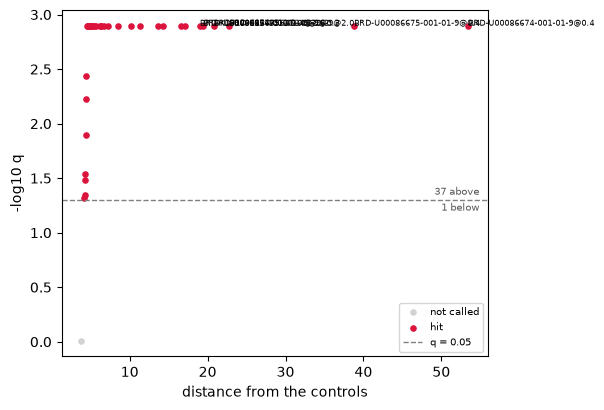

In [3]:
mt.tl.hit_calling(wells, groupby="Metadata_Perturbation", use_rep="X_pca", n_permutations=1000)
ax = mt.pl.hits(wells, label_top=6)
plt.show()

In [4]:
hits = wells.uns["mantispy"]["hits"].set_index("group")
hits.sort_values("distance", ascending=False).head(6)

,n_obs,distance,pvalue,qvalue,is_hit
group,,,,,
BRD-U00086674-001-01-9@0.4,64,53.490374,0.000999,0.001265,True
BRD-U00086675-001-01-9@0.4,64,38.818986,0.000999,0.001265,True
BRD-K95785537-001-26-9@2.0,32,22.780632,0.000999,0.001265,True
BRD-U00086675-001-01-9@0.2,64,20.770808,0.000999,0.001265,True
BRD-U00086674-001-01-9@0.2,64,19.452408,0.000999,0.001265,True
BRD-K15179513-001-03-4@2.0,32,19.016517,0.000999,0.001265,True


## Which features moved

A hit call says a treatment moved. It does not say what changed. {func}`~mantispy.tl.effect_size` gives a
per-feature effect against the controls with Mann-Whitney p-values, and one BH correction over the whole table.

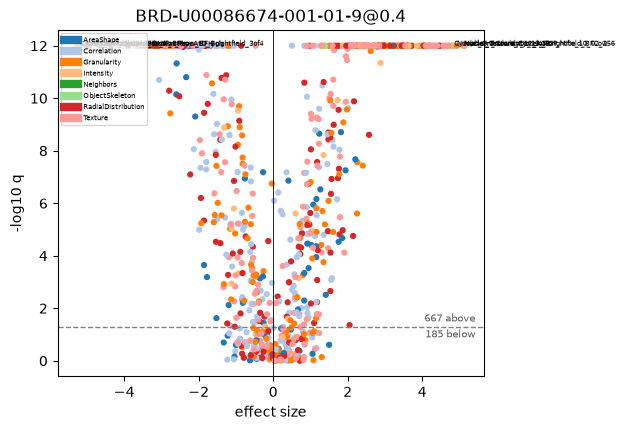

In [5]:
mt.tl.effect_size(wells, groupby="Metadata_Perturbation", reference="negcon")
strongest = hits.drop(index="DMSO")["distance"].idxmax()

ax = mt.pl.feature_volcano(wells, group=strongest)
ax.set_title(strongest)
plt.show()

Each point is one CellProfiler measurement. The named ones are where this compound's effect lives, and they are
the handle for the next question, whether two compounds move the same features, which is
[Mechanism of action](mechanism_of_action.ipynb).

## One profile per perturbation

Replicate wells of a treatment are combined into a signature with {func}`~mantispy.tl.consensus`.

In [6]:
signatures = mt.tl.consensus(wells, by="Metadata_Perturbation", method="median")
print(f"{wells.n_obs} wells -> {signatures.n_obs} signatures")
signatures

3072 wells -> 38 signatures


AnnData object with n_obs × n_vars = 38 × 852
    obs: 'Metadata_Perturbation', 'Metadata_ReplicateCount', 'Metadata_plate_map_name', 'Metadata_broad_sample', 'Metadata_mg_per_ml', 'Metadata_mmoles_per_liter', 'Metadata_solvent', 'Metadata_Site_Count', 'Metadata_Barcode', 'Metadata_Supplier', 'Metadata_Supplier_Catalog', 'Metadata_pert_type', 'Metadata_control_type', 'Metadata_Control', 'Metadata_Compound', 'Metadata_Concentration', 'Metadata_MOA'
    var: 'object', 'feature_group', 'feature', 'channel', 'scale', 'angle', 'gray_levels', 'radial_bin', 'params', 'is_feature', 'degenerate_scale', 'selected'
    uns: 'mantispy'
    layers: None (.X)

`median` is the default and is what pycytominer does by default. `modz` weights each replicate by how well it
agrees with the others, which helps when replicates are few and noisy.

## Is it a hit, or did the cells die?

A compound that kills four fifths of the cells leaves a well median computed from a fifth as
many cells, and that median moves away from the controls for reasons unrelated to the biology
being screened. It looks like a strong hit.

The cell count is also a baseline to beat. {cite:t}`Seal_2025` found that across three
bioactivity benchmarks a model given only the cell count often matched one given the whole
Cell Painting profile, and {cite:t}`Ewald_2026` found that profiles predicted LDH release no
better than cell count, plate and well position.

So that the answer is known in advance, this section uses a synthetic plate where one
perturbation is purely cytotoxic: 80% of its cells are removed and its injected morphology
effect is subtracted again. Only the cell loss remains.

In [7]:
plate = mt.ds.synthetic_plate(n_wells=192, n_cells=50, n_features=25, n_perturbations=3, effect_size=3.0, seed=0)
rng = np.random.default_rng(0)

toxic = (plate.obs["Metadata_Perturbation"] == "pert02").to_numpy()
plate = plate[~toxic | (rng.random(plate.n_obs) < 0.2)].copy()

rows = (plate.obs["Metadata_Perturbation"] == "pert02").to_numpy()
values = plate.X.copy()
for name in plate.uns["mantispy"]["truth"]["affected_features"]["pert02"]:
    column = list(plate.var_names).index(name)
    values[rows, column] -= values[rows, column].mean() - values[~rows, column].mean()
plate.X = values

mt.pp.normalize(plate, by="Metadata_Plate", reference="negcon")
wells = mt.tl.aggregate(plate, min_cells=0)
mt.tl.hit_calling(wells, n_permutations=500)
wells.uns["mantispy"]["hits"][["group", "distance", "qvalue", "is_hit"]].round(3)

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_38245/2037011891.py:16: UserWarning: the covariance is estimated from 24 of 48 reference rows (half the controls) for 25 features, so it is singular and the Mahalanobis distances are dominated by the regularization. Reduce the features with mt.pp.feature_select, or score a PCA representation with use_rep='X_pca'.
  mt.tl.hit_calling(wells, n_permutations=500)


,group,distance,qvalue,is_hit
0,DMSO,284.522,0.130,False
1,pert00,2831.307,0.003,True
2,pert01,2414.603,0.003,True
3,pert02,661.269,0.003,True


pert02 has no morphology effect left and is still called a hit, at 661 against 285 for the
controls. Hit calling cannot tell the difference, because nothing in the profile says why it
moved. (The covariance warning is the one described under calling hits above: 24 control rows for 25 features. It affects the scale of these
distances, not their order.)

In [8]:
mt.tl.cytotoxicity(wells)
wells.uns["mantispy"]["cytotoxicity"].round(3)

,group,n_obs,viability,distance,suspect
0,DMSO,48,1.0,78.961,False
1,pert00,48,1.0,2831.307,False
2,pert01,48,1.0,2414.603,False
3,pert02,48,0.2,661.269,True


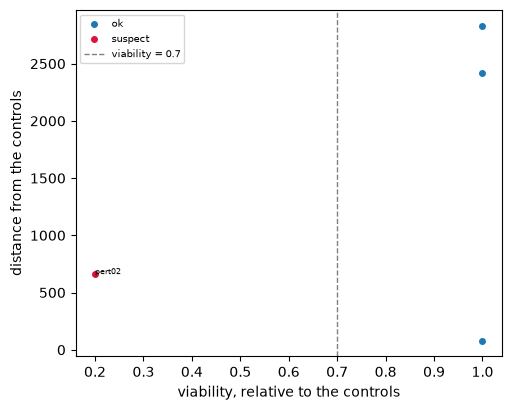

In [9]:
ax = mt.pl.cytotoxicity(wells)
plt.show()

`tl.cytotoxicity` reads each group's median `hits_row_distance`, the distance of each well on its own, which is
a different statistic from the hit caller's group distance. The treated groups agree between the two tables;
DMSO reads 79 here against 285 above.

pert02 has a viability of 0.20 and is the only group flagged. The two perturbations with real
effects and no cell loss are not flagged.

Both conditions have to hold. Cell loss alone is a phenotype (a compound that arrests growth
is a real finding), and a large distance alone is a hit. Only the combination is suspect.

`tl.cytotoxicity` is a diagnostic and does not correct anything.

## Summary

- A hit call says a treatment moved away from the controls. {func}`~mantispy.tl.effect_size` says which
  features moved, and {func}`~mantispy.tl.consensus` gives one signature per treatment.
- Cell loss and phenotype are confounded by construction. Flag the combination with
  {func}`~mantispy.tl.cytotoxicity` instead of correcting it away.

Next: [Mechanism of action](mechanism_of_action.ipynb), which asks whether two treatments moved the same way.